In [31]:
# ============================================================
# CELL 1 — INSTALL LIBRARIES
# ============================================================

!pip install river pandas numpy matplotlib pyyaml scikit-learn

In [45]:
# ============================================================
# CELL 2 — IMPORTS, FOLDERS, AND FILE PATHS
# ============================================================

import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from river import compose
from river import preprocessing
from river import linear_model
from river import metrics
from river import drift


# ----------------------------
# Input files
# ----------------------------
RETRIEVAL_FILE = "retrieval_results.csv"
CONFIG_FILE = "best_config.yaml"


# ----------------------------
# Output folders
# ----------------------------
OUTPUT_DIR = "outputs"
STRONG_DRIFT_DIR = os.path.join(OUTPUT_DIR, "strong_artificial_drift")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(STRONG_DRIFT_DIR, exist_ok=True)


# ----------------------------
# Real stream output files
# ----------------------------
OUTPUT_ONLINE_RESULTS = os.path.join(OUTPUT_DIR, "online_learning_results.csv")
OUTPUT_DRIFT_EVENTS = os.path.join(OUTPUT_DIR, "drift_events.csv")
OUTPUT_PREQ_PLOT = os.path.join(OUTPUT_DIR, "prequential_plot.png")
OUTPUT_ALPHA_PLOT = os.path.join(OUTPUT_DIR, "adaptive_alpha_plot.png")
OUTPUT_SUMMARY = os.path.join(OUTPUT_DIR, "person4_summary.csv")
OUTPUT_FINAL_TEXT_SUMMARY = os.path.join(OUTPUT_DIR, "person4_results_summary.txt")


# ----------------------------
# Strong artificial drift output files
# ----------------------------
STRONG_ARTIFICIAL_RESULTS_FILE = os.path.join(
    STRONG_DRIFT_DIR,
    "strong_artificial_drift_results.csv"
)

STRONG_ARTIFICIAL_DRIFT_EVENTS_FILE = os.path.join(
    STRONG_DRIFT_DIR,
    "strong_artificial_drift_events.csv"
)

STRONG_ARTIFICIAL_PLOT = os.path.join(
    STRONG_DRIFT_DIR,
    "strong_artificial_drift_plot.png"
)

In [46]:
# ============================================================
# CELL 3 — LOAD RETRIEVAL RESULTS
# ============================================================

retrieval_df = pd.read_csv(RETRIEVAL_FILE)

print("Retrieval file loaded successfully")
print("Shape:", retrieval_df.shape)
print("Columns:", retrieval_df.columns.tolist())

display(retrieval_df.head())

Retrieval file loaded successfully
Shape: (100, 12)
Columns: ['query_id', 'query', 'rank', 'chunk_id', 'relevant_chunk_id', 'tfidf_score', 'dense_score', 'hybrid_score', 'is_relevant', 'helpful', 'latency', 'alpha']


,query_id,query,rank,chunk_id,relevant_chunk_id,tfidf_score,dense_score,hybrid_score,is_relevant,helpful,latency,alpha
0,Q1,Technical Report Table 8: Statistical informat...,1,355,355,0.183881,0.409086,0.872512,1,1,0.034071,0.7
1,Q1,Technical Report Table 8: Statistical informat...,2,1392,355,0.143983,0.413619,0.812741,0,1,0.034071,0.7
2,Q1,Technical Report Table 8: Statistical informat...,3,338,355,0.143983,0.413619,0.812741,0,1,0.034071,0.7
3,Q1,Technical Report Table 8: Statistical informat...,4,1997,355,0.109337,0.440078,0.787279,0,1,0.034071,0.7
4,Q1,Technical Report Table 8: Statistical informat...,5,699,355,0.038991,0.517680,0.763614,0,1,0.034071,0.7


In [47]:
# ============================================================
# CELL 4 — LOAD BEST CONFIG FROM PERSON 3
# ============================================================

initial_alpha = 0.5

if os.path.exists(CONFIG_FILE):
    with open(CONFIG_FILE, "r") as f:
        config = yaml.safe_load(f)

    print("Best config loaded:")
    print(config)

    if isinstance(config, dict):
        if "alpha" in config:
            initial_alpha = float(config["alpha"])
        elif "hybrid_weight" in config:
            initial_alpha = float(config["hybrid_weight"])
        elif "best_params" in config and isinstance(config["best_params"], dict):
            if "alpha" in config["best_params"]:
                initial_alpha = float(config["best_params"]["alpha"])
            elif "hybrid_weight" in config["best_params"]:
                initial_alpha = float(config["best_params"]["hybrid_weight"])

print("Initial alpha from AutoML:", initial_alpha)

Best config loaded:
{'study_name': 'hybrid_retrieval_automl', 'n_trials': 40, 'best_trial': 31, 'seed': 42, 'parameters': {'k': 15, 'alpha': 0.6439308850863772, 'svd_dim': 500, 'normalization': False, 'metric': 'cosine'}, 'metrics': {'NDCG@5': 0.8479, 'Recall@5': 0.9667, 'P95_Latency': 0.0263}}
Initial alpha from AutoML: 0.5


In [48]:
# ============================================================
# CELL 5 — VALIDATE DATA AND CREATE HELPFUL FEEDBACK
# ============================================================

required_cols = [
    "query_id",
    "query",
    "rank",
    "chunk_id",
    "tfidf_score",
    "dense_score",
    "hybrid_score"
]

for col in required_cols:
    if col not in retrieval_df.columns:
        raise ValueError(f"Missing required column: {col}")

# If helpful column does not exist, create it from is_relevant
if "helpful" not in retrieval_df.columns:
    if "is_relevant" in retrieval_df.columns:
        helpful_map = (
            retrieval_df.groupby("query_id")["is_relevant"]
            .max()
            .astype(int)
            .to_dict()
        )
        retrieval_df["helpful"] = retrieval_df["query_id"].map(helpful_map)
    else:
        raise ValueError("Need either 'helpful' or 'is_relevant' column.")

retrieval_df["helpful"] = retrieval_df["helpful"].astype(int)

print("Helpful distribution per query:")
print(retrieval_df.groupby("query_id")["helpful"].first().value_counts())

Helpful distribution per query:
helpful
1    18
0     2
Name: count, dtype: int64


In [49]:
# ============================================================
# CELL 6 — CREATE QUERY-LEVEL STREAM
# ============================================================

query_rows = []

for query_id, group in retrieval_df.groupby("query_id"):

    group = group.sort_values("rank")
    top1 = group.iloc[0]

    tfidf_scores = group["tfidf_score"].astype(float).values
    dense_scores = group["dense_score"].astype(float).values
    hybrid_scores = group["hybrid_score"].astype(float).values

    helpful = int(group["helpful"].iloc[0])

    if len(group) > 1:
        tfidf_margin = tfidf_scores[0] - tfidf_scores[1]
        dense_margin = dense_scores[0] - dense_scores[1]
        hybrid_margin = hybrid_scores[0] - hybrid_scores[1]
    else:
        tfidf_margin = 0.0
        dense_margin = 0.0
        hybrid_margin = 0.0

    query_rows.append({
        "query_id": query_id,
        "query": top1["query"],
        "top1_chunk_id": top1["chunk_id"],

        "top1_tfidf_score": float(top1["tfidf_score"]),
        "top1_dense_score": float(top1["dense_score"]),
        "top1_hybrid_score": float(top1["hybrid_score"]),

        "mean_tfidf_top5": float(np.mean(tfidf_scores)),
        "mean_dense_top5": float(np.mean(dense_scores)),
        "mean_hybrid_top5": float(np.mean(hybrid_scores)),

        "max_tfidf_top5": float(np.max(tfidf_scores)),
        "max_dense_top5": float(np.max(dense_scores)),
        "max_hybrid_top5": float(np.max(hybrid_scores)),

        "tfidf_margin": float(tfidf_margin),
        "dense_margin": float(dense_margin),
        "hybrid_margin": float(hybrid_margin),

        "helpful": helpful
    })

stream_df = pd.DataFrame(query_rows)

print("Query-level stream created")
print("Shape:", stream_df.shape)

display(stream_df.head())

Query-level stream created
Shape: (20, 16)


,query_id,query,top1_chunk_id,top1_tfidf_score,top1_dense_score,top1_hybrid_score,mean_tfidf_top5,mean_dense_top5,mean_hybrid_top5,max_tfidf_top5,max_dense_top5,max_hybrid_top5,tfidf_margin,dense_margin,hybrid_margin,helpful
0,Q1,Technical Report Table 8: Statistical informat...,355,0.183881,0.409086,0.872512,0.124035,0.438816,0.809777,0.183881,0.517680,0.872512,0.039898,-0.004533,0.059772,1
1,Q10,Traditional RAG Retrieval Ranker Reader LongRA...,278,0.526431,0.675605,1.000000,0.342969,0.610426,0.836089,0.526431,0.675605,1.000000,0.130133,0.085193,0.151748,1
2,Q11,"design its usage. Generally speaking, the cont...",1894,0.183339,0.290616,0.815594,0.073335,0.378068,0.744543,0.183339,0.438636,0.815594,0.000000,0.000000,0.000000,1
3,Q12,Improving language models by retrieving from t...,142,0.269975,0.729917,0.978899,0.176724,0.713340,0.861154,0.269975,0.754684,0.978899,0.051434,0.019391,0.073675,1
4,Q13,Training Retriever Top-20 Top-100 NQ TriviaQA ...,416,0.432864,0.571401,0.852255,0.293291,0.624791,0.803635,0.438692,0.735306,0.852255,0.080715,-0.010877,0.045657,1


In [50]:
# ============================================================
# CELL 7 — ONLINE LEARNING FUNCTION
# ============================================================

def run_online_learning(
    input_stream_df,
    initial_alpha=0.5,
    learning_rate_alpha=0.05,
    adwin_delta=0.002,
    reset_on_drift=True
):
    """
    Runs River online learning with:
    - prequential evaluation
    - adaptive hybrid weight
    - ADWIN drift detection
    """

    model = compose.Pipeline(
        preprocessing.StandardScaler(),
        linear_model.LogisticRegression()
    )

    accuracy_metric = metrics.Accuracy()
    f1_metric = metrics.F1()
    adwin = drift.ADWIN(delta=adwin_delta)

    current_alpha = initial_alpha

    online_results = []
    drift_events = []

    for i, row in input_stream_df.iterrows():

        x = {
            "top1_tfidf_score": row["top1_tfidf_score"],
            "top1_dense_score": row["top1_dense_score"],
            "top1_hybrid_score": row["top1_hybrid_score"],
            "mean_tfidf_top5": row["mean_tfidf_top5"],
            "mean_dense_top5": row["mean_dense_top5"],
            "mean_hybrid_top5": row["mean_hybrid_top5"],
            "max_tfidf_top5": row["max_tfidf_top5"],
            "max_dense_top5": row["max_dense_top5"],
            "max_hybrid_top5": row["max_hybrid_top5"],
            "tfidf_margin": row["tfidf_margin"],
            "dense_margin": row["dense_margin"],
            "hybrid_margin": row["hybrid_margin"],
            "alpha": current_alpha
        }

        y_true = int(row["helpful"])

        # Predict before learning
        y_pred = model.predict_one(x)

        if y_pred is None:
            y_pred = 1

        y_pred = int(y_pred)

        y_proba = model.predict_proba_one(x)
        helpful_probability = y_proba.get(1, 0.5) if y_proba else 0.5

        # Prequential metric update
        accuracy_metric.update(y_true, y_pred)
        f1_metric.update(y_true, y_pred)

        current_accuracy = accuracy_metric.get()
        current_f1 = f1_metric.get()

        # ADWIN monitors prediction error
        error = int(y_true != y_pred)
        adwin.update(error)

        drift_detected = False

        if hasattr(adwin, "drift_detected"):
            drift_detected = adwin.drift_detected

        if drift_detected:
            drift_events.append({
                "step": i + 1,
                "query_id": row["query_id"],
                "accuracy_at_drift": current_accuracy,
                "f1_at_drift": current_f1,
                "alpha_at_drift": current_alpha,
                "adwin_width": adwin.width,
                "adwin_estimation": adwin.estimation
            })

            if reset_on_drift:
                model = compose.Pipeline(
                    preprocessing.StandardScaler(),
                    linear_model.LogisticRegression()
                )

                current_alpha = 0.5 * current_alpha + 0.5 * initial_alpha

        # Learn after evaluation
        model.learn_one(x, y_true)

        # Adaptive alpha update
        dense_advantage = row["top1_dense_score"] - row["top1_tfidf_score"]

        if y_true == 1:
            current_alpha += learning_rate_alpha * dense_advantage
        else:
            current_alpha -= learning_rate_alpha * dense_advantage

        current_alpha = max(0.05, min(0.95, current_alpha))

        online_results.append({
            "step": i + 1,
            "query_id": row["query_id"],
            "query": row["query"],
            "y_true_helpful": y_true,
            "y_pred_helpful": y_pred,
            "helpful_probability": helpful_probability,
            "prediction_error": error,
            "prequential_accuracy": current_accuracy,
            "prequential_f1": current_f1,
            "adaptive_alpha": current_alpha,
            "drift_detected": int(drift_detected)
        })

    return pd.DataFrame(online_results), pd.DataFrame(drift_events)

In [52]:
# ============================================================
# CELL 8 — RUN REAL STREAM EXPERIMENT
# ============================================================

online_results_df, drift_events_df = run_online_learning(
    input_stream_df=stream_df,
    initial_alpha=initial_alpha,
    learning_rate_alpha=0.05,
    adwin_delta=0.002,
    reset_on_drift=True
)

online_results_df.to_csv(OUTPUT_ONLINE_RESULTS, index=False)
drift_events_df.to_csv(OUTPUT_DRIFT_EVENTS, index=False)

print("Real online learning complete")
print("Final prequential accuracy:", online_results_df["prequential_accuracy"].iloc[-1])
print("Final prequential F1:", online_results_df["prequential_f1"].iloc[-1])
print("Final adaptive alpha:", online_results_df["adaptive_alpha"].iloc[-1])
print("Number of drift events:", len(drift_events_df))

display(online_results_df.head())
display(drift_events_df)

Real online learning complete
Final prequential accuracy: 0.75
Final prequential F1: 0.8571428571428571
Final adaptive alpha: 0.6570891864710869
Number of drift events: 0


,step,query_id,query,y_true_helpful,y_pred_helpful,helpful_probability,prediction_error,prequential_accuracy,prequential_f1,adaptive_alpha,drift_detected
0,1,Q1,Technical Report Table 8: Statistical informat...,1,0,0.500000,1,0.000000,0.000000,0.511260,0
1,2,Q10,Traditional RAG Retrieval Ranker Reader LongRA...,1,1,0.501250,0,0.500000,0.666667,0.518719,0
2,3,Q11,"design its usage. Generally speaking, the cont...",1,0,0.475621,1,0.333333,0.500000,0.524083,0
3,4,Q12,Improving language models by retrieving from t...,1,1,0.507068,0,0.500000,0.666667,0.547080,0
4,5,Q13,Training Retriever Top-20 Top-100 NQ TriviaQA ...,1,1,0.521752,0,0.600000,0.750000,0.554007,0


""


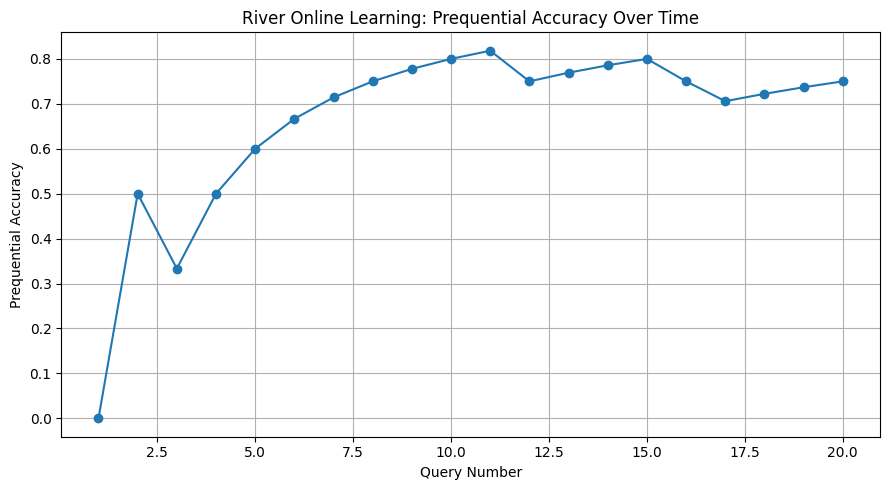

Saved: outputs/prequential_plot.png


In [53]:
# ============================================================
# CELL 9 — PLOT REAL PREQUENTIAL ACCURACY
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(
    online_results_df["step"],
    online_results_df["prequential_accuracy"],
    marker="o"
)

for _, event in drift_events_df.iterrows():
    plt.axvline(x=event["step"], linestyle="--", label="ADWIN Drift")

plt.xlabel("Query Number")
plt.ylabel("Prequential Accuracy")
plt.title("River Online Learning: Prequential Accuracy Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_PREQ_PLOT, dpi=300)
plt.show()



print("Saved:", OUTPUT_PREQ_PLOT)

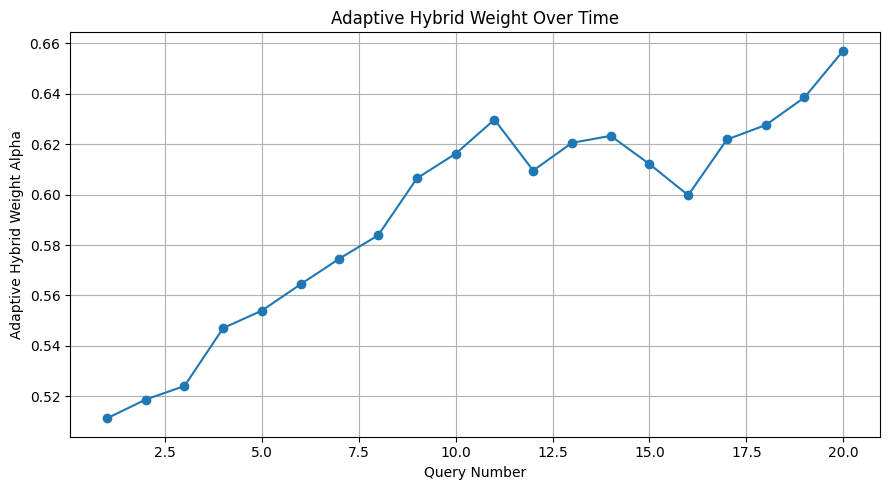

Saved: outputs/adaptive_alpha_plot.png


In [54]:
# ============================================================
# CELL 10 — PLOT ADAPTIVE HYBRID WEIGHT
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(
    online_results_df["step"],
    online_results_df["adaptive_alpha"],
    marker="o"
)

plt.xlabel("Query Number")
plt.ylabel("Adaptive Hybrid Weight Alpha")
plt.title("Adaptive Hybrid Weight Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_ALPHA_PLOT, dpi=300)
plt.show()

print("Saved:", OUTPUT_ALPHA_PLOT)

In [55]:
# ============================================================
# CELL 11 — SAVE PERSON 4 SUMMARY
# ============================================================

summary = {
    "Initial alpha from AutoML": initial_alpha,
    "Final adaptive alpha": online_results_df["adaptive_alpha"].iloc[-1],
    "Final prequential accuracy": online_results_df["prequential_accuracy"].iloc[-1],
    "Final prequential F1": online_results_df["prequential_f1"].iloc[-1],
    "Number of queries": len(online_results_df),
    "Number of drift events": len(drift_events_df)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTPUT_SUMMARY, index=False)

display(summary_df)

print("Saved:", OUTPUT_SUMMARY)

,Initial alpha from AutoML,Final adaptive alpha,Final prequential accuracy,Final prequential F1,Number of queries,Number of drift events
0,0.5,0.657089,0.75,0.857143,20,0


Saved: outputs/person4_summary.csv


ARTIFICIAL DRIFT EXPERIMENT

Strong artificial drift stream created
Total artificial stream length: 100
Artificial drift starts at step: 51

Helpful distribution before drift:
helpful
1    50
Name: count, dtype: int64

Helpful distribution after drift:
helpful
0    50
Name: count, dtype: int64

Strong artificial drift experiment complete
Number of strong artificial drift events: 1
Saved: outputs/strong_artificial_drift/strong_artificial_drift_results.csv
Saved: outputs/strong_artificial_drift/strong_artificial_drift_events.csv


,step,query_id,accuracy_at_drift,f1_at_drift,alpha_at_drift,adwin_width,adwin_estimation
0,64,S64,0.75,0.857143,0.819935,40.0,0.35


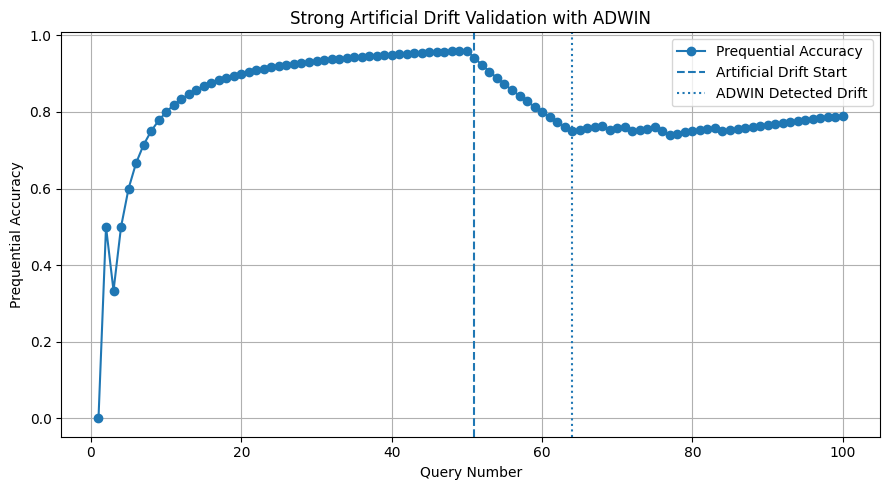

Saved: outputs/strong_artificial_drift/strong_artificial_drift_plot.png


In [56]:
# ============================================================
# CELL 12 — STRONG ARTIFICIAL DRIFT STREAM AND ADWIN VALIDATION
# ============================================================

# The original real stream only contains 20 queries.
# This is too short for ADWIN to reliably detect statistical drift.
# Therefore, we repeat the stream to create a longer controlled stream.

long_stream_df = pd.concat([stream_df] * 5, ignore_index=True)

# Create new query IDs to avoid duplicates
long_stream_df["query_id"] = ["S" + str(i + 1) for i in range(len(long_stream_df))]

midpoint_long = len(long_stream_df) // 2

# Force strong artificial drift:
# First half: all feedback labels are helpful
# Second half: all feedback labels are not helpful
long_stream_df.loc[:midpoint_long - 1, "helpful"] = 1
long_stream_df.loc[midpoint_long:, "helpful"] = 0

print("Strong artificial drift stream created")
print("Total artificial stream length:", len(long_stream_df))
print("Artificial drift starts at step:", midpoint_long + 1)

print("\nHelpful distribution before drift:")
print(long_stream_df.loc[:midpoint_long - 1, "helpful"].value_counts())

print("\nHelpful distribution after drift:")
print(long_stream_df.loc[midpoint_long:, "helpful"].value_counts())


# Run River + ADWIN on the strong artificial drift stream
strong_artificial_results_df, strong_artificial_drift_events_df = run_online_learning(
    input_stream_df=long_stream_df,
    initial_alpha=initial_alpha,
    learning_rate_alpha=0.05,
    adwin_delta=0.1,
    reset_on_drift=True
)

# Save artificial drift results inside outputs/strong_artificial_drift/
strong_artificial_results_df.to_csv(STRONG_ARTIFICIAL_RESULTS_FILE, index=False)
strong_artificial_drift_events_df.to_csv(STRONG_ARTIFICIAL_DRIFT_EVENTS_FILE, index=False)

print("\nStrong artificial drift experiment complete")
print("Number of strong artificial drift events:", len(strong_artificial_drift_events_df))
print("Saved:", STRONG_ARTIFICIAL_RESULTS_FILE)
print("Saved:", STRONG_ARTIFICIAL_DRIFT_EVENTS_FILE)

display(strong_artificial_drift_events_df)


# Plot artificial drift result
plt.figure(figsize=(9, 5))

plt.plot(
    strong_artificial_results_df["step"],
    strong_artificial_results_df["prequential_accuracy"],
    marker="o",
    label="Prequential Accuracy"
)

# Show where artificial drift starts
plt.axvline(
    x=midpoint_long + 1,
    linestyle="--",
    label="Artificial Drift Start"
)

# Show ADWIN detected drift event(s)
for _, event in strong_artificial_drift_events_df.iterrows():
    plt.axvline(
        x=event["step"],
        linestyle=":",
        label="ADWIN Detected Drift" if _ == 0 else None
    )

plt.xlabel("Query Number")
plt.ylabel("Prequential Accuracy")
plt.title("Strong Artificial Drift Validation with ADWIN")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot inside outputs/strong_artificial_drift/
plt.savefig(STRONG_ARTIFICIAL_PLOT, dpi=300)
plt.show()

print("Saved:", STRONG_ARTIFICIAL_PLOT)

In [57]:
# ============================================================
# CELL 13 — CREATE FINAL SUMMARY TEXT FILE
# ============================================================

summary_txt_file = OUTPUT_FINAL_TEXT_SUMMARY

# ----------------------------
# Real stream results
# ----------------------------
initial_alpha_value = initial_alpha
final_alpha_value = online_results_df["adaptive_alpha"].iloc[-1]
final_accuracy_value = online_results_df["prequential_accuracy"].iloc[-1]
final_f1_value = online_results_df["prequential_f1"].iloc[-1]
num_real_queries = len(online_results_df)
num_real_drift_events = len(drift_events_df)

# ----------------------------
# Strong artificial drift results
# ----------------------------
num_strong_queries = len(strong_artificial_results_df)
num_strong_drift_events = len(strong_artificial_drift_events_df)

if num_strong_drift_events > 0:
    first_drift_step = int(strong_artificial_drift_events_df.iloc[0]["step"])
    first_drift_query_id = strong_artificial_drift_events_df.iloc[0]["query_id"]
    drift_accuracy = float(strong_artificial_drift_events_df.iloc[0]["accuracy_at_drift"])
    drift_f1 = float(strong_artificial_drift_events_df.iloc[0]["f1_at_drift"])
    drift_alpha = float(strong_artificial_drift_events_df.iloc[0]["alpha_at_drift"])
    adwin_width = float(strong_artificial_drift_events_df.iloc[0]["adwin_width"])
    adwin_estimation = float(strong_artificial_drift_events_df.iloc[0]["adwin_estimation"])

    drift_accuracy_text = f"{drift_accuracy:.4f}"
    drift_f1_text = f"{drift_f1:.4f}"
    drift_alpha_text = f"{drift_alpha:.4f}"
    adwin_width_text = f"{adwin_width:.2f}"
    adwin_estimation_text = f"{adwin_estimation:.4f}"

else:
    first_drift_step = "Not detected"
    first_drift_query_id = "Not detected"
    drift_accuracy_text = "N/A"
    drift_f1_text = "N/A"
    drift_alpha_text = "N/A"
    adwin_width_text = "N/A"
    adwin_estimation_text = "N/A"


summary_text = f"""
PERSON 4 — RIVER ONLINE LEARNING AND ADWIN SUMMARY
==================================================

1. Original / Real Online Learning Experiment
--------------------------------------------

The original online learning experiment was performed using the real retrieval stream generated from the gold queries and the top-5 retrieval results.

Each unique query was treated as one streaming instance. For every query, the River model first predicted whether the retrieval result would be helpful. The prediction was then evaluated using the true feedback label, and finally the model was updated. This follows the prequential evaluation approach: predict, evaluate, then learn.

The feedback label was defined as follows:
- helpful = 1 if the relevant chunk appeared in the top-5 retrieved chunks.
- helpful = 0 if the relevant chunk did not appear in the top-5 retrieved chunks.

Original stream results:
- Number of real queries: {num_real_queries}
- Initial hybrid weight alpha from AutoML: {initial_alpha_value:.4f}
- Final adaptive hybrid weight alpha: {final_alpha_value:.4f}
- Final prequential accuracy: {final_accuracy_value:.4f}
- Final prequential F1 score: {final_f1_value:.4f}
- Number of real ADWIN drift events: {num_real_drift_events}

Interpretation:
The online learner achieved a final prequential accuracy of {final_accuracy_value:.4f} and a final F1 score of {final_f1_value:.4f}. The adaptive hybrid weight increased from {initial_alpha_value:.4f} to {final_alpha_value:.4f}. This indicates that the system gradually shifted toward relying more on dense semantic retrieval compared with TF-IDF lexical retrieval.

2. Explanation of Zero Drift in the Real Stream
-----------------------------------------------

ADWIN detected zero drift events in the original real stream. This is expected because the real stream contained only {num_real_queries} queries and the feedback behavior was relatively stable.

ADWIN is a statistical drift detector. It needs a sustained and meaningful change in the prediction error stream before it raises a drift alert. Therefore, zero detected drift in the real stream does not mean that the ADWIN implementation failed. It means that the real query stream did not contain a strong enough distribution shift for ADWIN to detect.

3. Strong Artificial Drift Validation
-------------------------------------

Because the real stream was short and stable, a strong artificial drift experiment was added to verify that the ADWIN drift detector works correctly.

In this artificial experiment, the original stream was repeated five times to create a longer controlled stream. Then, the feedback behavior was deliberately changed halfway through the stream:
- First half: feedback labels were forced to be helpful.
- Second half: feedback labels were forced to be not helpful.

This creates a clear concept drift scenario where the feedback distribution changes suddenly.

Strong artificial drift results:
- Number of artificial streaming instances: {num_strong_queries}
- Number of strong artificial drift events detected: {num_strong_drift_events}
- First detected drift step: {first_drift_step}
- First detected drift query ID: {first_drift_query_id}
- Accuracy at detected drift: {drift_accuracy_text}
- F1 score at detected drift: {drift_f1_text}
- Alpha at detected drift: {drift_alpha_text}
- ADWIN window width at drift: {adwin_width_text}
- ADWIN error estimation at drift: {adwin_estimation_text}

Interpretation:
In the strong artificial drift experiment, ADWIN detected {num_strong_drift_events} drift event(s). The first drift was detected at step {first_drift_step}. This confirms that the ADWIN component is functioning correctly when a significant distribution shift is introduced.

4. Final Conclusion
-------------------

The Person 4 component successfully implemented:
- River-based online learning
- adaptive hybrid weighting
- prequential evaluation
- ADWIN drift detection

The real stream showed stable behavior with no detected drift, while the strong artificial drift validation confirmed that ADWIN can detect concept drift when the feedback distribution changes significantly.

Generated output files:
- outputs/online_learning_results.csv
- outputs/drift_events.csv
- outputs/person4_summary.csv
- outputs/prequential_accuracy_plot.png
- outputs/adaptive_alpha_plot.png
- outputs/person4_results_summary.txt
- outputs/strong_artificial_drift/strong_artificial_drift_results.csv
- outputs/strong_artificial_drift/strong_artificial_drift_events.csv
- outputs/strong_artificial_drift/strong_artificial_drift_plot.png
"""

with open(summary_txt_file, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_txt_file)
print(summary_text)

Saved: outputs/person4_results_summary.txt

PERSON 4 — RIVER ONLINE LEARNING AND ADWIN SUMMARY

1. Original / Real Online Learning Experiment
--------------------------------------------

The original online learning experiment was performed using the real retrieval stream generated from the gold queries and the top-5 retrieval results.

Each unique query was treated as one streaming instance. For every query, the River model first predicted whether the retrieval result would be helpful. The prediction was then evaluated using the true feedback label, and finally the model was updated. This follows the prequential evaluation approach: predict, evaluate, then learn.

The feedback label was defined as follows:
- helpful = 1 if the relevant chunk appeared in the top-5 retrieved chunks.
- helpful = 0 if the relevant chunk did not appear in the top-5 retrieved chunks.

Original stream results:
- Number of real queries: 20
- Initial hybrid weight alpha from AutoML: 0.5000
- Final adaptive hy

In [58]:
# ============================================================
# CELL 14 — FINAL OUTPUT CHECK
# ============================================================

expected_files = [
    OUTPUT_ONLINE_RESULTS,
    OUTPUT_DRIFT_EVENTS,
    OUTPUT_SUMMARY,
    OUTPUT_PREQ_PLOT,
    OUTPUT_ALPHA_PLOT,
    OUTPUT_FINAL_TEXT_SUMMARY,
    STRONG_ARTIFICIAL_RESULTS_FILE,
    STRONG_ARTIFICIAL_DRIFT_EVENTS_FILE,
    STRONG_ARTIFICIAL_PLOT
]

print("Checking final output files...\n")

for file in expected_files:
    if os.path.exists(file):
        print("FOUND:", file)
    else:
        print("MISSING:", file)

Checking final output files...

FOUND: outputs/online_learning_results.csv
FOUND: outputs/drift_events.csv
FOUND: outputs/person4_summary.csv
FOUND: outputs/prequential_plot.png
FOUND: outputs/adaptive_alpha_plot.png
FOUND: outputs/person4_results_summary.txt
FOUND: outputs/strong_artificial_drift/strong_artificial_drift_results.csv
FOUND: outputs/strong_artificial_drift/strong_artificial_drift_events.csv
FOUND: outputs/strong_artificial_drift/strong_artificial_drift_plot.png
